In [1]:
import sys
print(sys.executable)

import site
print(site.getsitepackages())


e:\Anaconda\envs\tf-gpu\python.exe
['e:\\Anaconda\\envs\\tf-gpu', 'e:\\Anaconda\\envs\\tf-gpu\\lib\\site-packages']


In [11]:
# ==============================
# 1. Install & Import Library
# ==============================
%pip install yfinance deap tensorflow pandas numpy matplotlib scikit-learn

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from deap import base, creator, tools, algorithms
import tensorflow as tf
import joblib

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping


Note: you may need to restart the kernel to use updated packages.


In [3]:
# ==============================
# 2. Ambil Data Brent Crude Oil
# ==============================
df = yf.download("BZ=F", start="2022-12-30", end="2026-06-22")
df = df[['Close']].dropna() #apakah pada penelitian lain yang dipakai harga close.
#Perlu informasi awal dataset, e.g data ada berapa
display(df.head())
df.info()
# Pastikan semua data float64
df = df.astype("float64")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_19716\3689485660.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("BZ=F", start="2022-12-30", end="2026-06-22")
[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,BZ=F
Date,
2022-12-30,85.910004
2023-01-03,82.099998
2023-01-04,77.839996
2023-01-05,78.690002
2023-01-06,78.570000


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 872 entries, 2022-12-30 to 2026-06-18
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, BZ=F)  872 non-null    float64
dtypes: float64(1)
memory usage: 13.6 KB


In [4]:
# ==============================
# 3. Preprocessing
# ==============================
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df)

def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i, 0])
        y.append(data[i, 0])
    return np.array(X, dtype=np.float64), np.array(y, dtype=np.float64)

time_step = 60
X, y = create_dataset(scaled_data, time_step)

# Ubah ke bentuk 3D untuk LSTM
X = np.reshape(X, (X.shape[0], X.shape[1], 1)).astype("float64")

# Split data train-test
train_size = int(len(X) * 0.70) #ini perlu alasan kenapa 70:15:15
val_size = int(len(X) * 0.15)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

print("Train :", X_train.shape)
print("Validation :", X_val.shape)
print("Test :", X_test.shape)

Train : (568, 60, 1)
Validation : (121, 60, 1)
Test : (123, 60, 1)


gen	nevals	avg    	std    	min    	max    
0  	20    	1.77153	0.43323	1.03326	2.43729
1  	15    	1.46207	0.278396	1.03326	1.9986 
2  	12    	1.2665 	0.16746 	1.0315 	1.64402
3  	11    	1.15219	0.284829	1.0315 	2.35676
4  	8     	1.09394	0.133987	1.01379	1.6362 
5  	13    	1.03911	0.0199309	1.01379	1.09312
6  	9     	1.09615	0.202716 	1.01379	1.91197
7  	17    	1.08544	0.167046 	1.01239	1.65195
8  	7     	1.05322	0.127177 	1.01379	1.58537
9  	15    	1.14069	0.245793 	1.01319	1.86906
10 	12    	1.05321	0.105436 	1.01414	1.50127
11 	13    	1.0776 	0.174243 	1.007  	1.71443
12 	15    	1.0824 	0.190913 	1.007  	1.83058
13 	13    	1.0552 	0.13121  	1.0096 	1.60904
14 	15    	1.02349	0.0161146	1.0096 	1.07524
15 	10    	1.05035	0.147445 	1.0096 	1.69279
16 	10    	1.02998	0.0556671	1.00785	1.27008
17 	11    	1.05377	0.128272 	1.00785	1.58312
18 	14    	1.05826	0.144311 	1.00785	1.68239
19 	15    	1.02791	0.0488775	1.00702	1.23805
20 	10    	1.05206	0.163081 	1.00702	1.76234
Best Hyperparamete

,gen,nevals,avg,std,min,max
0,0,20,1.771530,0.433230,1.033257,2.437292
1,1,15,1.462067,0.278396,1.033257,1.998603
2,2,12,1.266502,0.167460,1.031499,1.644023
3,3,11,1.152185,0.284829,1.031499,2.356757
4,4,8,1.093944,0.133987,1.013793,1.636198
5,5,13,1.039110,0.019931,1.013793,1.093116
6,6,9,1.096149,0.202716,1.013793,1.911971
7,7,17,1.085437,0.167046,1.012389,1.651950
8,8,7,1.053215,0.127177,1.013793,1.585374
9,9,15,1.140691,0.245793,1.013195,1.869062


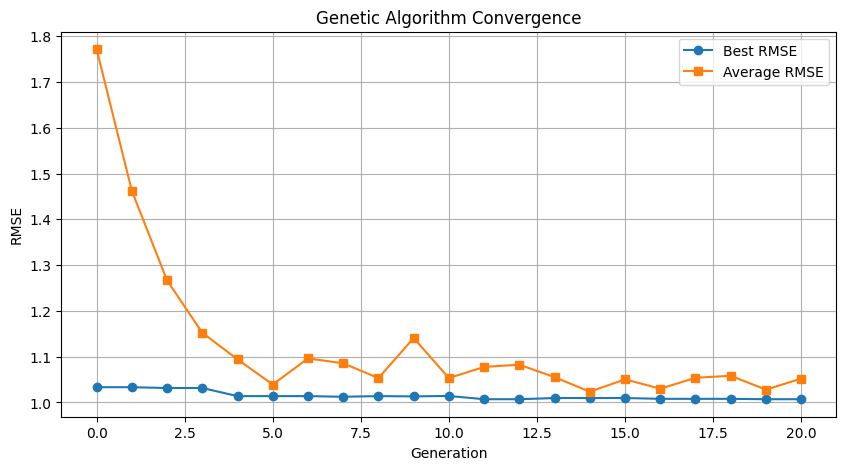

In [5]:
# ==============================
# 4. Genetic Algorithm (GA)
# ==============================
# parameter2 yang ada di LSTM apa saja gunanya.
param_space = {
    "units": [32, 64, 128, 256],
    "dropout": [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5],
    "learning_rate": [0.001, 0.0005, 0.0001],
    "batch_size": [16, 32, 64],
    "epochs": [50, 100, 150]
}

# Fitness function
def evaluate(individual):
    #clear session tensrflow
    K.clear_session()
    
    # Access hyperparameters by index and cast to expected types
    units = int(individual[0])
    dropout = float(individual[1])
    lr = float(individual[2])
    batch_size = int(individual[3])
    epochs = int(individual[4])
    

    # The check for units <= 0 is no longer strictly necessary with the custom mutation,
    # but keeping it can help catch unexpected issues.
    if units <= 0:
         print(f"Warning: Invalid units value encountered: {units}. Penalizing individual.")
         return (float('inf'),) # Penalize individuals with invalid units


    model = Sequential()
    model.add(LSTM(units, return_sequences=True, input_shape=(time_step, 1)))
    model.add(Dropout(dropout))
    model.add(LSTM(units))
    model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=lr), loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)

    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_val, y_val),callbacks=[early_stop], verbose=0)

    pred = model.predict(X_val, verbose=0)
    pred_inv = scaler.inverse_transform(pred)
    y_val_inv = scaler.inverse_transform(y_val.reshape(-1, 1))

    rmse = np.sqrt(mean_squared_error(y_val_inv, pred_inv)) #RMSE, MSE, MAE
    
    del model # Clear model from memory to avoid clutter
    return (rmse,)
# Setup GA
if "FitnessMin" not in creator.__dict__:
    creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
if "Individual" not in creator.__dict__:
    creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()
toolbox.register("attr_units", lambda: random.choice(param_space["units"]))
toolbox.register("attr_dropout", lambda: random.choice(param_space["dropout"]))
toolbox.register("attr_lr", lambda: random.choice(param_space["learning_rate"]))
toolbox.register("attr_batch", lambda: random.choice(param_space["batch_size"]))
toolbox.register("attr_epochs", lambda: random.choice(param_space["epochs"]))

# Explicitly zip attribute functions with names for clearer mapping
toolbox.register("individual", tools.initCycle, creator.Individual,
                 (toolbox.attr_units, toolbox.attr_dropout, toolbox.attr_lr,
                  toolbox.attr_batch, toolbox.attr_epochs), n=1)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxTwoPoint)

# Custom mutation to ensure units stay within valid range
def custom_mutate(individual, indpb):
    for i in range(len(individual)):
        if random.random() < indpb:
            if i == 0: # Index 0 is units
                individual[i] = random.choice(param_space["units"])
            elif i == 1: # Index 1 is dropout
                 individual[i] = random.choice(param_space["dropout"])
            elif i == 2: # Index 2 is learning_rate
                 individual[i] = random.choice(param_space["learning_rate"])
            elif i == 3: # Index 3 is batch_size
                 individual[i] = random.choice(param_space["batch_size"])
            elif i == 4: # Index 4 is epochs
                 individual[i] = random.choice(param_space["epochs"])
    return individual,

toolbox.register("mutate", custom_mutate, indpb=0.2)

toolbox.register("select", tools.selTournament, tournsize=3)

stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("std", np.std)
stats.register("min", np.min)
stats.register("max", np.max)

# Jalankan GA
population = toolbox.population(n=20)
NGEN = 20
population, logbook = algorithms.eaSimple(population, toolbox, cxpb=0.5, mutpb=0.3, ngen=NGEN, stats=stats, verbose=True)

best_individual = tools.selBest(population, k=1)[0]
print("Best Hyperparameters Found:", best_individual)

print(f"""
Units         : {best_individual[0]}
Dropout       : {best_individual[1]}
Learning Rate : {best_individual[2]}
Batch Size    : {best_individual[3]}
Epochs        : {best_individual[4]}
""")

#logbook
print(logbook)
log_df = pd.DataFrame(logbook)
display(log_df)
log_df.to_csv("GA_Logbook.csv", index=False)

#Grafik konergensi GA
plt.figure(figsize=(10,5))
plt.plot(log_df["gen"], log_df["min"], marker="o", label="Best RMSE")
plt.plot(log_df["gen"], log_df["avg"], marker="s", label="Average RMSE")
plt.xlabel("Generation")
plt.ylabel("RMSE")
plt.title("Genetic Algorithm Convergence")
plt.legend()
plt.grid(True)

plt.show()

Epoch 1/100
36/36 [==============================] - 4s 34ms/step - loss: 0.0084 - val_loss: 0.0016
Epoch 2/100
36/36 [==============================] - 1s 16ms/step - loss: 0.0033 - val_loss: 0.0012
Epoch 3/100
36/36 [==============================] - 1s 17ms/step - loss: 0.0024 - val_loss: 0.0010
Epoch 4/100
36/36 [==============================] - 1s 18ms/step - loss: 0.0026 - val_loss: 9.0998e-04
Epoch 5/100
36/36 [==============================] - 1s 18ms/step - loss: 0.0023 - val_loss: 0.0012
Epoch 6/100
36/36 [==============================] - 1s 17ms/step - loss: 0.0023 - val_loss: 0.0010
Epoch 7/100
36/36 [==============================] - 1s 17ms/step - loss: 0.0021 - val_loss: 6.9866e-04
Epoch 8/100
36/36 [==============================] - 1s 18ms/step - loss: 0.0019 - val_loss: 7.2250e-04
Epoch 9/100
36/36 [==============================] - 1s 17ms/step - loss: 0.0022 - val_loss: 7.6779e-04
Epoch 10/100
36/36 [==============================] - 1s 16ms/step - loss: 0.0017 - 

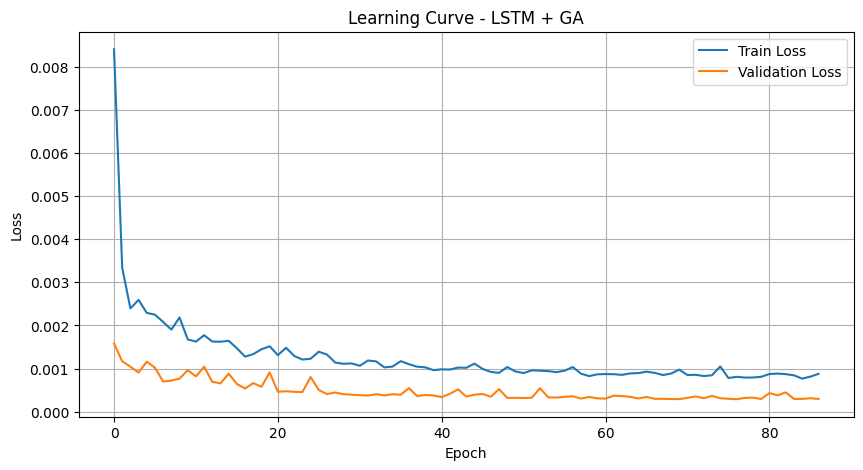

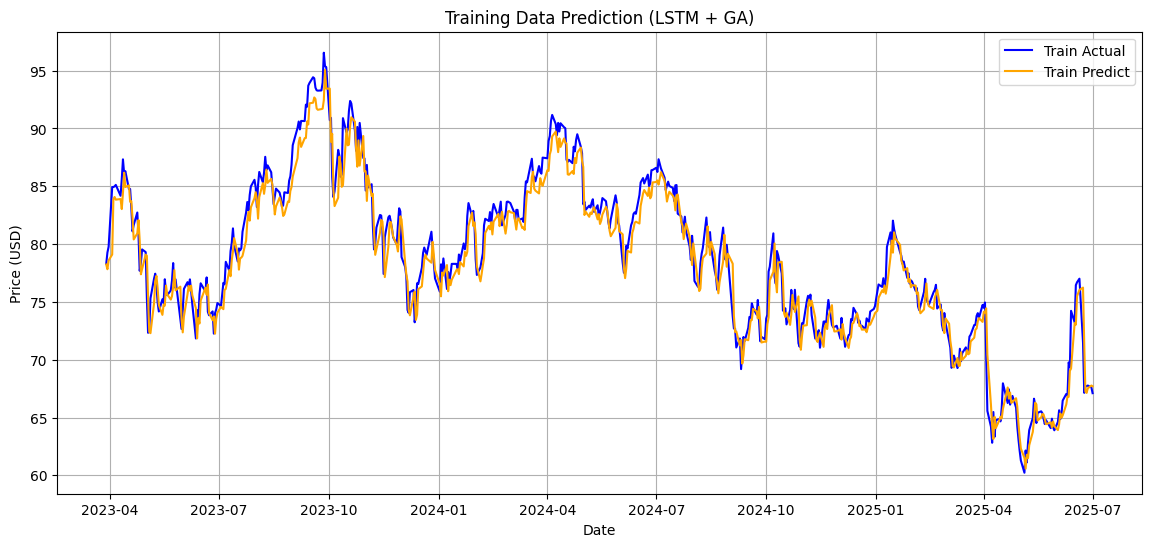

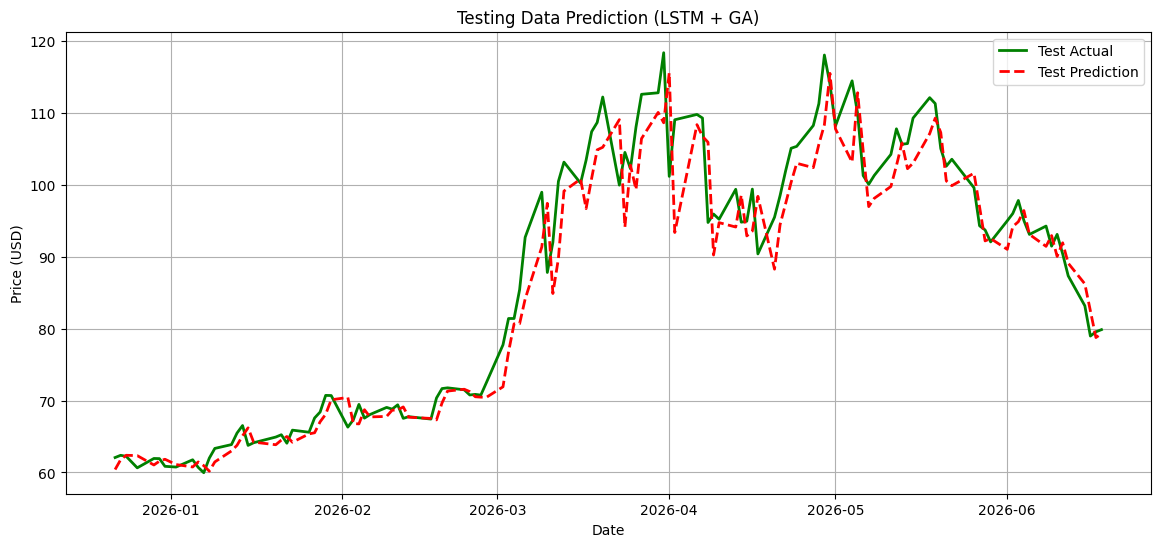

Final Model RMSE: 4.59
Final Model MAE : 3.28
Final Model MAPE: 3.49%
Final Model R^2 : 0.9354


['model/scaler.pkl']

In [12]:
# ==============================
# 5. Model Final + Evaluasi
# ==============================
def build_and_train_final_model(best_individual, X_train, y_train,X_val, y_val, X_test, y_test, scaler, df, time_step, train_size, val_size):
    units, dropout, lr, batch_size, epochs = best_individual

    K.clear_session()  # Clear previous models from memory

    model = Sequential()
    model.add(LSTM(units, return_sequences=True, input_shape=(time_step, 1)))
    model.add(Dropout(dropout))
    model.add(LSTM(units))
    model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=lr), loss='mean_squared_error')
    
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
                        validation_data=(X_val, y_val), callbacks=[early_stopping], verbose=1)
    


    # Learning curve
    plt.figure(figsize=(10,5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Learning Curve - LSTM + GA')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Prediksi
    train_pred = model.predict(X_train, verbose=0)
    test_pred = model.predict(X_test, verbose=0)

    train_pred_inv = scaler.inverse_transform(train_pred)
    test_pred_inv = scaler.inverse_transform(test_pred)
    y_train_inv = scaler.inverse_transform(y_train.reshape(-1, 1))
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

    train_index = df.index[time_step:train_size+time_step]
    test_start = train_size + val_size + time_step
    test_index = df.index[test_start:]
    
    # Grafik Training
    plt.figure(figsize=(14,6))
    plt.plot(train_index, y_train_inv, label="Train Actual", color='blue')
    plt.plot(train_index, train_pred_inv, label="Train Predict", color='orange')
    plt.title("Training Data Prediction (LSTM + GA)")
    plt.xlabel("Date")
    plt.ylabel("Price (USD)")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Grafik Testing
    plt.figure(figsize=(14,6))
    plt.plot(test_index, y_test_inv, label="Test Actual", linewidth=2, color='green')
    plt.plot(test_index, test_pred_inv, label="Test Prediction", linestyle='--', linewidth=2, color='red')
    plt.title("Testing Data Prediction (LSTM + GA)")
    plt.xlabel("Date")
    plt.ylabel("Price (USD)")
    plt.legend()
    plt.grid(True)
    plt.show()

    #evaluasi model
    rmse = np.sqrt(mean_squared_error(y_test_inv, test_pred_inv))
    mae = mean_absolute_error(y_test_inv, test_pred_inv)
    mape = np.mean(np.abs((y_test_inv - test_pred_inv) / y_test_inv)) * 100
    r2 = r2_score(y_test_inv, test_pred_inv)

    print(f"Final Model RMSE: {rmse:.2f}")
    print(f"Final Model MAE : {mae:.2f}")
    print(f"Final Model MAPE: {mape:.2f}%")
    print(f"Final Model R^2 : {r2:.4f}")

    return model

final_model = build_and_train_final_model(best_individual, X_train, y_train, X_val, y_val, X_test, y_test,
                                          scaler, df, time_step, train_size, val_size)

final_model.save("model/lstm_ga_brent.keras")
joblib.dump(scaler, "model/scaler.pkl")

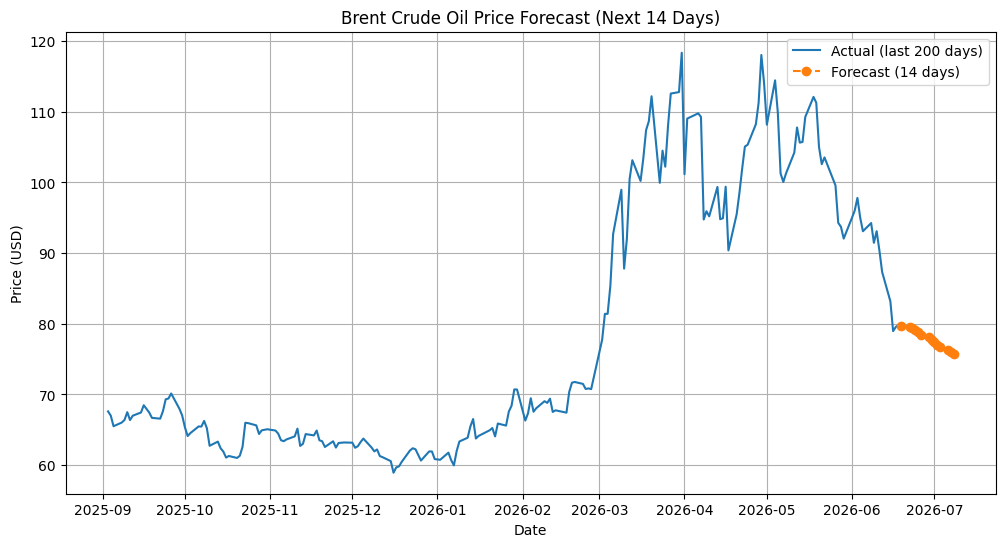

In [7]:
# ==============================
# 6. Forecast Future
# ==============================
def forecast_future(model, df, scaler, time_step=60, n_days=14):
    last_sequence = df['Close'].values[-time_step:]
    last_sequence_scaled = scaler.transform(last_sequence.reshape(-1, 1))
    input_seq = last_sequence_scaled.reshape(1, time_step, 1)

    future_preds = []
    for _ in range(n_days):
        next_pred = model.predict(input_seq, verbose=0)
        future_preds.append(next_pred[0,0])
        # Reshape next_pred to (1, 1, 1) before appending
        input_seq = np.append(input_seq[:,1:,:], next_pred.reshape(1, 1, 1), axis=1)

    future_preds = scaler.inverse_transform(np.array(future_preds).reshape(-1,1))
    last_date = df.index[-1]
    future_dates = pd.date_range(last_date, periods=n_days+1, freq="B")[1:]
    return future_dates, future_preds

future_dates, future_preds = forecast_future(final_model, df, scaler, time_step, n_days=14)

plt.figure(figsize=(12,6))
plt.plot(df.index[-200:], df['Close'].values[-200:], label="Actual (last 200 days)")
plt.plot(future_dates, future_preds, label="Forecast (14 days)", linestyle="--", marker="o")
plt.title("Brent Crude Oil Price Forecast (Next 14 Days)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid()
plt.show()

In [8]:
# ==============================
# 7. Simpan Forecast ke CSV
# ==============================
def save_forecast_to_csv(future_dates, future_preds, filename="brent_forecast_14days.csv"):
    forecast_df = pd.DataFrame({
        "Date": future_dates,
        "Predicted_Price": future_preds.flatten()
    })
    forecast_df.to_csv(filename, index=False)
    print(f"Hasil forecast disimpan ke {filename}")

save_forecast_to_csv(future_dates, future_preds, "brent_forecast_14days.csv")

Hasil forecast disimpan ke brent_forecast_14days.csv
